## Model and Training

## Load pretrained ResNet-18

In [3]:
import torch
from torchvision.models import resnet18, ResNet18_Weights

# Use torchvision directly (already installed) instead of torch.hub — simpler and
# guaranteed compatible with your versions. weights=DEFAULT grabs the best
# available ImageNet-pretrained weights (downloaded & cached once, ~45 MB).
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# The final layer ('fc') currently outputs 1000 classes (ImageNet). We'll swap it
# for a 5-class layer in the next step.
print('Final layer before swap:', model.fc)

Final layer before swap: Linear(in_features=512, out_features=1000, bias=True)


## Swap final layer for 5 classes

In [4]:
import torch.nn as nn

NUM_CLASSES = 5

# 1) Freeze the pretrained backbone — keep its learned features, don't update them.
for param in model.parameters():
    param.requires_grad = False

# 2) Replace the final layer with a fresh one for OUR 5 classes.
#    New layers default to requires_grad=True, so ONLY this head will train.
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

# 3) Move the whole model to the GPU (or CPU if somehow unavailable).
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

# Report what we built.
print('Device      :', device)
print('New final layer:', model.fc)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} of {total:,}  (only the new head)')

Device      : cuda
New final layer: Linear(in_features=512, out_features=5, bias=True)
Trainable params: 2,565 of 11,179,077  (only the new head)


## Load data

In [5]:
# Get the data pipeline from src/data.py (one line, thanks to the refactor!).
# We add '..' to the path so Python can find the project's src/ package,
# since this notebook lives in notebooks/.
import sys
sys.path.append('..')
from src.data import get_dataloaders

train_loader, val_loader, test_loader, classes = get_dataloaders(data_dir='../data', batch_size=32)
print('Classes:', classes)
print('Batches -> train:', len(train_loader),
      '| val:', len(val_loader),
      '| test:', len(test_loader))

Classes: ['Boeing 737', 'A320', 'A340', 'Boeing 777', 'A380']
Batches -> train: 20 | val: 20 | test: 20


## Loss + optimizer

In [6]:
import torch.optim as optim

# Loss: CrossEntropyLoss is the standard for multi-class classification.
# It measures how far the model's 5 scores are from the correct answer.
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam, told to update ONLY the trainable params (our new head).
# lr (learning rate) = how big each weight update is. 1e-3 is a solid default.
optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-3)

EPOCHS = 8  # how many full passes over the training data
print('Loss + optimizer ready. Training for', EPOCHS, 'epochs.')

Loss + optimizer ready. Training for 8 epochs.


## Training loop

In [7]:
def run_epoch(loader, train):
    """Run ONE pass over `loader`.
    If train=True, also update the model's weights. Returns (avg_loss, accuracy).
    """
    model.train() if train else model.eval()   # set the right mode
    total_loss, correct, total = 0.0, 0, 0

    # Track gradients only while training (faster + less memory when evaluating).
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)  # -> GPU

            outputs = model(images)            # forward pass: 5 scores per image
            loss = criterion(outputs, labels)  # how wrong were we?

            if train:
                optimizer.zero_grad()          # clear leftover gradients
                loss.backward()                # compute gradients (backprop)
                optimizer.step()               # nudge weights to reduce loss

            # Bookkeeping for reporting.
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)      # prediction = class with top score
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


# --- the training loop ---
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    print(f'Epoch {epoch:2d}/{EPOCHS} | '
          f'train loss {train_loss:.3f} acc {train_acc:.3f} | '
          f'val loss {val_loss:.3f} acc {val_acc:.3f}')

print('\nDone training!')

Epoch  1/8 | train loss 1.455 acc 0.408 | val loss 1.314 acc 0.470
Epoch  2/8 | train loss 1.274 acc 0.509 | val loss 1.252 acc 0.524
Epoch  3/8 | train loss 1.141 acc 0.551 | val loss 1.196 acc 0.540
Epoch  4/8 | train loss 1.079 acc 0.588 | val loss 1.159 acc 0.549
Epoch  5/8 | train loss 1.024 acc 0.602 | val loss 1.143 acc 0.562
Epoch  6/8 | train loss 0.951 acc 0.679 | val loss 1.111 acc 0.576
Epoch  7/8 | train loss 0.891 acc 0.700 | val loss 1.078 acc 0.611
Epoch  8/8 | train loss 0.857 acc 0.689 | val loss 1.088 acc 0.600

Done training!


## Evaluate properly: balanced accuracy, macro-F1, confusion matrix

In [8]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, classification_report)


@torch.no_grad()
def collect_predictions(loader):
    """Run the model over a loader and return (y_pred, y_true) as numpy arrays."""
    model.eval()
    preds, trues = [], []
    for images, labels in loader:
        outputs = model(images.to(device))
        preds.append(outputs.argmax(dim=1).cpu())
        trues.append(labels)
    return torch.cat(preds).numpy(), torch.cat(trues).numpy()


y_pred, y_true = collect_predictions(val_loader)

print(f'Overall accuracy : {accuracy_score(y_true, y_pred):.3f}')
print(f'Balanced accuracy: {balanced_accuracy_score(y_true, y_pred):.3f}')
print(f'Macro F1         : {f1_score(y_true, y_pred, average="macro"):.3f}')
print()
# Per-class precision / recall / F1 / support (how many images per class).
print(classification_report(y_true, y_pred, target_names=classes, digits=3))

Overall accuracy : 0.600
Balanced accuracy: 0.500
Macro F1         : 0.519

              precision    recall  f1-score   support

  Boeing 737      0.695     0.695     0.695       266
        A320      0.482     0.692     0.568       133
        A340      0.598     0.526     0.560       133
  Boeing 777      0.490     0.373     0.424        67
        A380      1.000     0.212     0.350        33

    accuracy                          0.600       632
   macro avg      0.653     0.500     0.519       632
weighted avg      0.624     0.600     0.593       632



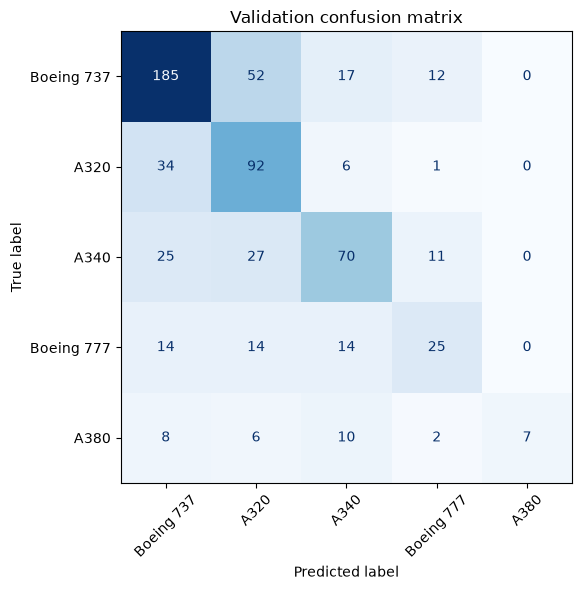

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
ax.set_title('Validation confusion matrix')
plt.tight_layout()
plt.show()

# Rows = true class, columns = predicted class.
# The diagonal = correct. Big off-diagonal numbers = which pairs get confused.

## Phase 2: class weights + fine-tuning the backbone

In [10]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# --- FIX 1: class weights (targets the A380/777 problem) ---
# Rarer classes get a higher weight, so the loss punishes mistakes on them more.
# Computed from the TRAINING labels only (never peek at val/test).
train_ds = train_loader.dataset
train_targets = np.array([train_ds.old_to_new[train_ds.base._labels[i]]
                          for i in train_ds.indices])
weights_arr = compute_class_weight('balanced',
                                   classes=np.arange(NUM_CLASSES), y=train_targets)
class_weights = torch.tensor(weights_arr, dtype=torch.float32, device=device)

print('Class weights (higher = rarer = penalised more):')
for name, w in zip(classes, weights_arr):
    print(f'  {name:11s} {w:.2f}')

criterion = nn.CrossEntropyLoss(weight=class_weights)

# --- FIX 2: unfreeze the backbone (targets the 60% ceiling) ---
for p in model.parameters():
    p.requires_grad = True

# New optimizer over ALL params, with a LOW learning rate (1e-4) so we gently
# adapt the pretrained features instead of wrecking them. weight_decay adds a
# little regularisation to fight overfitting on our small dataset.
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nFine-tuning ALL {trainable:,} params at lr=1e-4, with weighted loss.')

Class weights (higher = rarer = penalised more):
  Boeing 737  0.47
  A320        0.95
  A340        0.95
  Boeing 777  1.92
  A380        3.72

Fine-tuning ALL 11,179,077 params at lr=1e-4, with weighted loss.


In [ ]:
# Fine-tuning loop. We reuse run_epoch() — it reads the global `criterion` and
# `optimizer`, which we just replaced, so it now does weighted-loss fine-tuning.
EPOCHS = 12
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    print(f'Epoch {epoch:2d}/{EPOCHS} | '
          f'train loss {train_loss:.3f} acc {train_acc:.3f} | '
          f'val loss {val_loss:.3f} acc {val_acc:.3f}')

print('\nFine-tuning done! Now re-run the two evaluation cells above to compare.')

Epoch  1/12 | train loss 0.797 acc 0.742 | val loss 0.893 acc 0.639
Epoch  2/12 | train loss 0.315 acc 0.891 | val loss 0.728 acc 0.742
Epoch  3/12 | train loss 0.132 acc 0.972 | val loss 0.630 acc 0.774
Epoch  4/12 | train loss 0.076 acc 0.981 | val loss 0.662 acc 0.764
Epoch  5/12 | train loss 0.056 acc 0.994 | val loss 0.729 acc 0.729
Epoch  6/12 | train loss 0.029 acc 0.998 | val loss 0.636 acc 0.796
Epoch  7/12 | train loss 0.021 acc 1.000 | val loss 0.503 acc 0.832
Epoch  8/12 | train loss 0.017 acc 0.998 | val loss 0.536 acc 0.821


## Save the model + final test-set evaluation

In [ ]:
from pathlib import Path

# Save the trained weights so we never have to retrain to use the model.
# Best practice: save the state_dict (the weights), plus the info needed to
# rebuild and interpret it (architecture + class order).
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)
ckpt_path = MODELS_DIR / 'resnet18_aircraft5.pt'

torch.save({
    'arch': 'resnet18',
    'classes': classes,          # so inference knows 0->Boeing 737, etc.
    'state_dict': model.state_dict(),
}, ckpt_path)

print('Saved model to:', ckpt_path.resolve())

In [ ]:
# THE HONEST EXAM: evaluate on the test set — touched for the FIRST time, now
# that all our tuning decisions (fine-tuning, class weights) are locked in.
# This number is what you report as the model's real-world performance.
y_pred_test, y_true_test = collect_predictions(test_loader)

print('=== FINAL TEST SET RESULTS (first and only look) ===')
print(f'Overall accuracy : {accuracy_score(y_true_test, y_pred_test):.3f}')
print(f'Balanced accuracy: {balanced_accuracy_score(y_true_test, y_pred_test):.3f}')
print(f'Macro F1         : {f1_score(y_true_test, y_pred_test, average="macro"):.3f}')
print()
print(classification_report(y_true_test, y_pred_test, target_names=classes, digits=3))

## Evaluate properly: balanced accuracy, macro-F1, confusion matrix

In [ ]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, classification_report)


@torch.no_grad()
def collect_predictions(loader):
    """Run the model over a loader and return (y_pred, y_true) as numpy arrays."""
    model.eval()
    preds, trues = [], []
    for images, labels in loader:
        outputs = model(images.to(device))
        preds.append(outputs.argmax(dim=1).cpu())
        trues.append(labels)
    return torch.cat(preds).numpy(), torch.cat(trues).numpy()


y_pred, y_true = collect_predictions(val_loader)

print(f'Overall accuracy : {accuracy_score(y_true, y_pred):.3f}')
print(f'Balanced accuracy: {balanced_accuracy_score(y_true, y_pred):.3f}')
print(f'Macro F1         : {f1_score(y_true, y_pred, average="macro"):.3f}')
print()
# Per-class precision / recall / F1 / support (how many images per class).
print(classification_report(y_true, y_pred, target_names=classes, digits=3))

Overall accuracy : 0.600
Balanced accuracy: 0.500
Macro F1         : 0.519

              precision    recall  f1-score   support

  Boeing 737      0.695     0.695     0.695       266
        A320      0.482     0.692     0.568       133
        A340      0.598     0.526     0.560       133
  Boeing 777      0.490     0.373     0.424        67
        A380      1.000     0.212     0.350        33

    accuracy                          0.600       632
   macro avg      0.653     0.500     0.519       632
weighted avg      0.624     0.600     0.593       632



## Evaluate properly: balanced accuracy, macro-F1, confusion matrix

In [ ]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, classification_report)


@torch.no_grad()
def collect_predictions(loader):
    """Run the model over a loader and return (y_pred, y_true) as numpy arrays."""
    model.eval()
    preds, trues = [], []
    for images, labels in loader:
        outputs = model(images.to(device))
        preds.append(outputs.argmax(dim=1).cpu())
        trues.append(labels)
    return torch.cat(preds).numpy(), torch.cat(trues).numpy()


y_pred, y_true = collect_predictions(val_loader)

print(f'Overall accuracy : {accuracy_score(y_true, y_pred):.3f}')
print(f'Balanced accuracy: {balanced_accuracy_score(y_true, y_pred):.3f}')
print(f'Macro F1         : {f1_score(y_true, y_pred, average="macro"):.3f}')
print()
# Per-class precision / recall / F1 / support (how many images per class).
print(classification_report(y_true, y_pred, target_names=classes, digits=3))

Overall accuracy : 0.600
Balanced accuracy: 0.500
Macro F1         : 0.519

              precision    recall  f1-score   support

  Boeing 737      0.695     0.695     0.695       266
        A320      0.482     0.692     0.568       133
        A340      0.598     0.526     0.560       133
  Boeing 777      0.490     0.373     0.424        67
        A380      1.000     0.212     0.350        33

    accuracy                          0.600       632
   macro avg      0.653     0.500     0.519       632
weighted avg      0.624     0.600     0.593       632



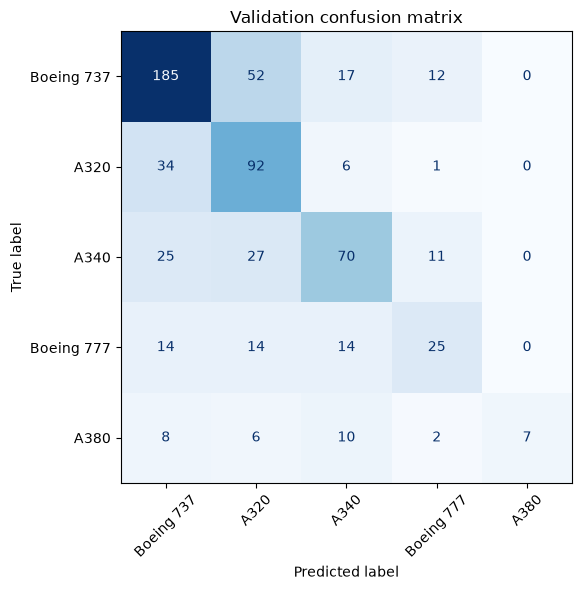

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
ax.set_title('Validation confusion matrix')
plt.tight_layout()
plt.show()

# Rows = true class, columns = predicted class.
# The diagonal = correct. Big off-diagonal numbers = which pairs get confused.